# CSE4114  Pattern Recognition & Machine Learning Lab <br> Implementing K-Means Clustering <br> Assignment 4
# **Name:** Mirza Naeem Beg <br> **Id:** 20210204033 <br> **Section:** A2

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random

### Task 1: Load the data and plot all the points

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4187485607.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("data_k_mean.txt", sep="\s+", header=None, names=["x", "y"])


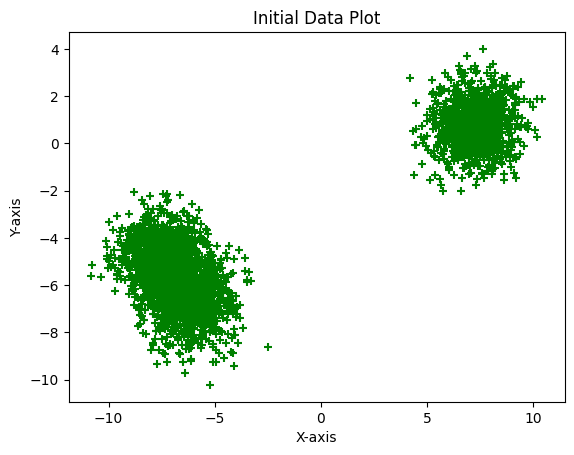

In [36]:
df = pd.read_csv("data_k_mean.txt", sep="\s+", header=None, names=["x", "y"])

#plot
plt.scatter(df['x'], df['y'], c='green', marker='+')
plt.title("Initial Data Plot")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

### Task 2: Perform K-Means clustering with K=2

In [37]:
k = 2

# Randomly choose initial centroids
initial_centroids_idx = random.sample(range(len(df)), k)
centroids = df.iloc[initial_centroids_idx][['x', 'y']].to_numpy()

def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

def assign_clusters(df, centroids):
    clusters = []
    for point in df[['x', 'y']].to_numpy():
        distances = [euclidean_distance(point, centroid) for centroid in centroids]
        cluster = np.argmin(distances)
        clusters.append(cluster)
    return np.array(clusters)

# Update centroids
def update_centroids(df, clusters, k):
    new_centroids = []
    for i in range(k):
        cluster_points = df[['x', 'y']].to_numpy()[clusters == i]
        # Handle empty clusters
        if len(cluster_points) > 0:
            new_centroids.append(cluster_points.mean(axis=0))
        else:
            new_centroids.append(df[['x', 'y']].sample(1).to_numpy()[0])
    return np.array(new_centroids)

# K-Means
while True:
    clusters = assign_clusters(df, centroids)
    new_centroids = update_centroids(df, clusters, k)
    if np.allclose(centroids, new_centroids):
        break
    centroids = new_centroids

# Cluster assignments to dataframe
df['cluster'] = clusters
df

,x,y,cluster
0,-7.87157,-4.86573,1
1,-4.76661,-6.87944,1
2,-6.67986,-5.83080,1
3,-8.93021,-4.15571,1
4,-7.91375,-4.22840,1
...,...,...,...
2995,-8.06037,-4.84080,1
2996,7.47328,0.37321,0
2997,6.91832,-0.32132,0
2998,-8.23828,-4.00405,1


### Task 3: Plot the clustered points with different colors

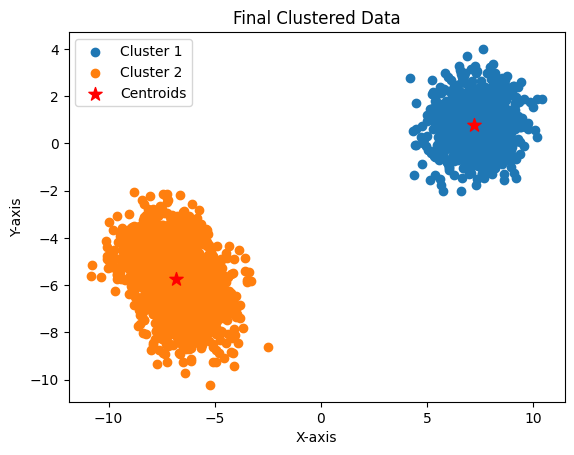

In [38]:
# Final clustered plot
for i in range(k):
    cluster_points = df[df['cluster'] == i]
    plt.scatter(cluster_points['x'], cluster_points['y'], label=f'Cluster {i+1}')

plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='*', s=100, label='Centroids')
plt.title("Final Clustered Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()
